In [ ]:
import json 
import os
import sys
import numpy as np 
import pandas as pd 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from dataset.paths import VQA_QUESTIONS, VQA_ANNOT, VQA_IMAGE_DIR, VQA_1K 

sem = "/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl"
sem_data = []
with open(sem, 'r') as f:
    for line in f:
        sem_data.append(json.loads(line)) 
sdf = pd.DataFrame(sem_data)

with open('/home/david/Desktop/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json', 'r') as f : 
    hdf = json.load(f)
    
hqids = np.array([question[0]['qid'] for question in hdf], dtype=np.int64)
hsdf = sdf[sdf['question_id'].isin(hqids)]
len(hsdf), len(hqids)   

In [ ]:
from dataset.vqav2 import VQADataset
from extract_vqa import get_vqa_questions  

questions = get_vqa_questions() 
qids = [d['question_id'] for d in questions]  
 
dataset = VQADataset( image_dir_path="/home/david/Desktop/yuna/data/val2014", 
                        question_path=VQA_QUESTIONS, 
                        annotations_path=VQA_ANNOT, 
                        prompt='', format=False)  

loaded 1000 questions from VQA validation 1k 
e.g.
{'image_id': 524577, 'question': 'What number of clocks are on this tower?', 'question_id': 524577006}
{'image_id': 262148, 'question': 'Where is he looking?', 'question_id': 262148000, 'question_type': 'none of the above', 'multiple_choice_answer': 'down', 'answers': [{'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'at table', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'skateboard', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'table', 'answer_confidence': 'yes', 'answer_id': 6}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 9}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 10}], 'answer_type': 'other', 'i

In [3]:
unique_counts = sdf.apply(lambda x: x.map(tuple) if isinstance(x.iloc[0], list) else x).nunique()
print(unique_counts)

image_id        980
question        969
question_id    1000
w                11
op               12
p               102
sub             601
obj             344
ent               9
attr             10
ans              12
space             4
sp               13
rel              16
dx                8
neg               1
know              2
txt               2
q                 2
dtype: int64


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L12-v2")   

In [ ]:
X = model.encode(hqs, normalize_embeddings=True) 

for qtype in ['w', 'op', 'ent', 'attr', 'ans', 'space']  : 

    labels = get_labels(qtype, hsdf, hqs) 
    labels = [str(label) if label is None else label for label in labels] 
    unique_labels = sorted(set(labels)) 
    print(len(unique_labels), unique_labels)
    visualize_by_semantics(qtype, labels, unique_labels)    

969 969
11 ['how', 'how_long', 'how_many', 'how_old', 'other', 'what', 'where', 'which', 'who', 'why', 'yesno']


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


<Figure size 640x480 with 0 Axes>

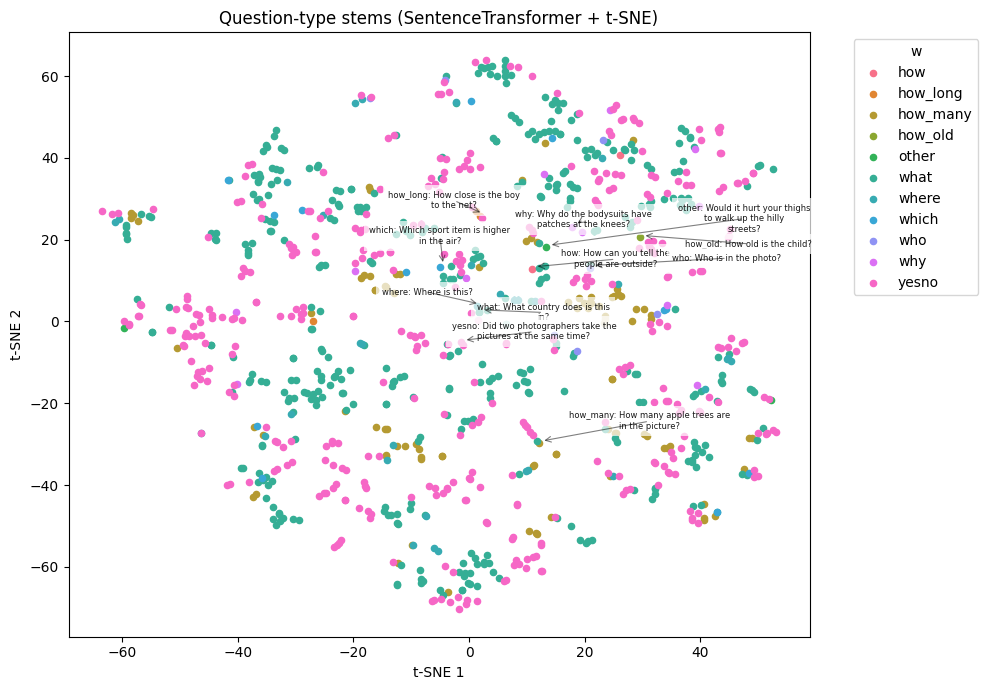

969 969
12 ['act', 'attr', 'cause', 'comp', 'count', 'exist', 'ident', 'know', 'other', 'spat', 'temp', 'text']


<Figure size 640x480 with 0 Axes>

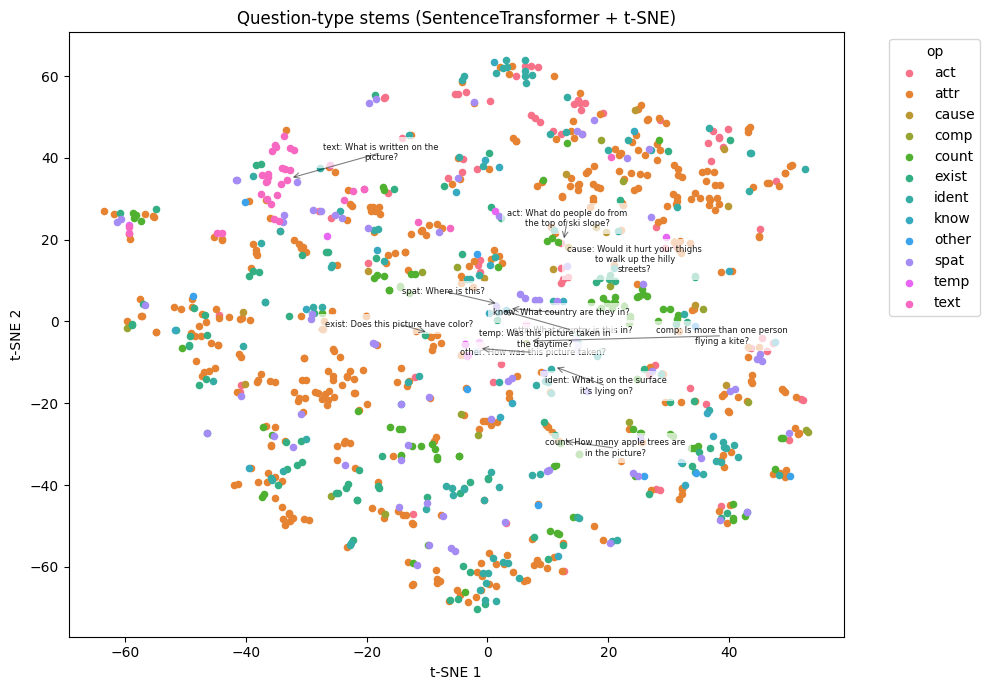

969 969
9 ['animal', 'food', 'object', 'other', 'person', 'place', 'product', 'text', 'vehicle']


<Figure size 640x480 with 0 Axes>

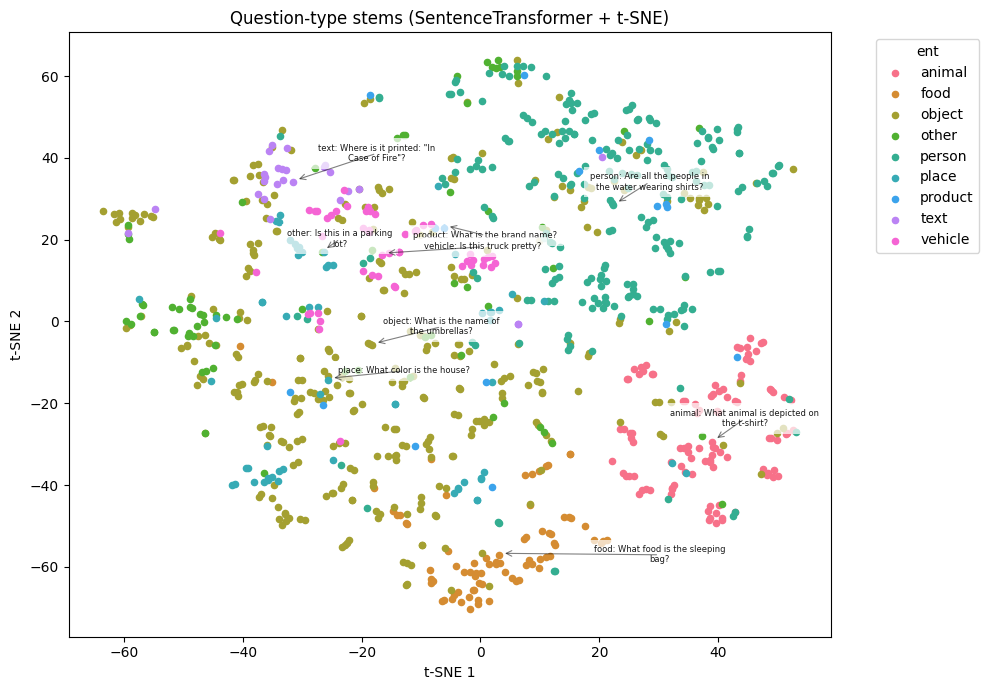

969 969
11 ['None', 'age', 'color', 'count', 'dur', 'ident', 'loc', 'mat', 'name', 'other', 'type']


<Figure size 640x480 with 0 Axes>

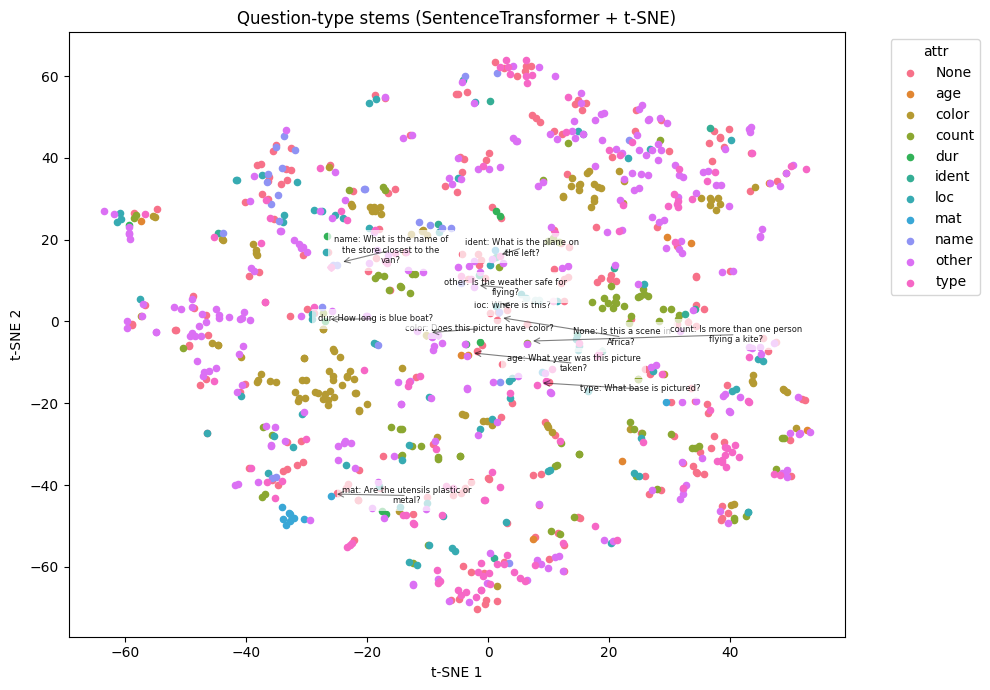

969 969
12 ['age', 'bool', 'cat', 'color', 'dur', 'loc', 'mat', 'num', 'object', 'open', 'person', 'text']


<Figure size 640x480 with 0 Axes>

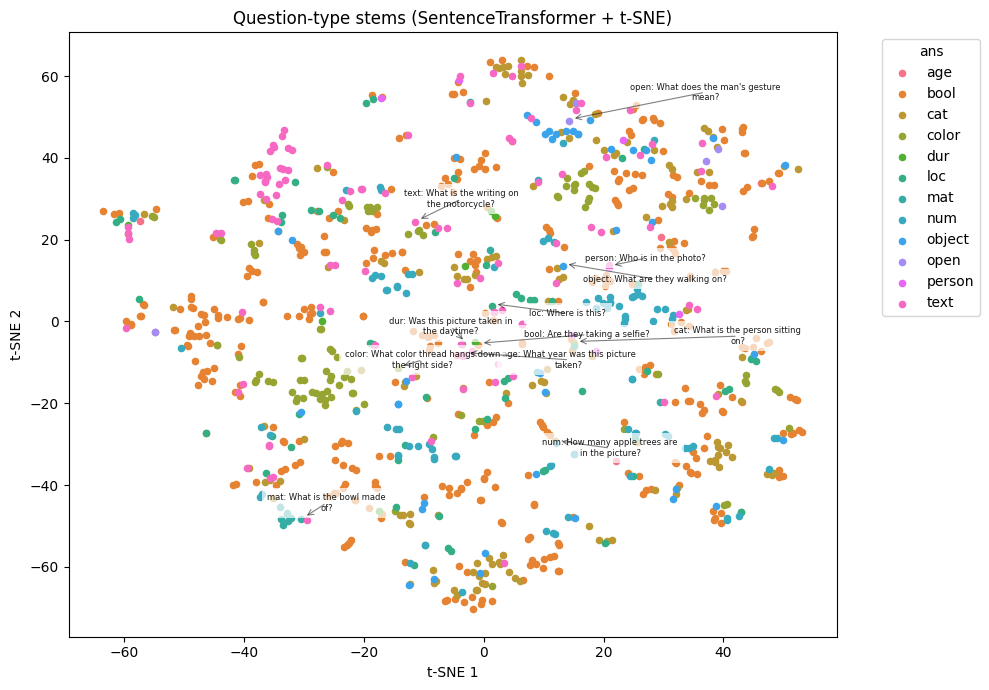

969 969
4 ['bin', 'cat', 'num', 'open']


<Figure size 640x480 with 0 Axes>

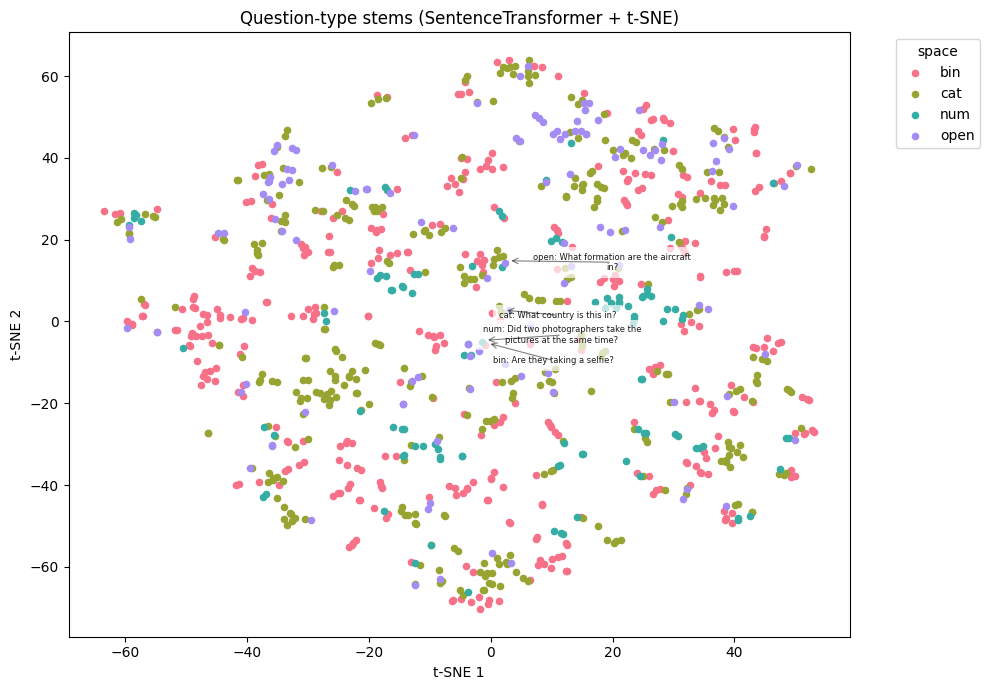

In [ ]:
for qtype in ['w', 'op', 'ent', 'attr', 'ans', 'space']  : 

    labels = get_labels(qtype, sdf, qs ) 
    labels = [str(label) if label is None else label for label in labels]  
    unique_labels = sorted(set(labels)) 
    print(len(unique_labels), unique_labels)
    visualize_by_semantics(qtype, labels, unique_labels)   

In [ ]:
examples = [q for q in dataset if q['question_type'] == 'none of the above']
for i, example in enumerate(examples[:5]):  # show first 5 examples
    print(f"{example}")

{'image_id': 262148, 'question': 'Where is he looking?', 'question_id': 262148000, 'question_type': 'none of the above', 'multiple_choice_answer': 'down', 'answers': [{'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'at table', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'skateboard', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'table', 'answer_confidence': 'yes', 'answer_id': 6}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 9}, {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 10}], 'answer_type': 'other', 'image': '/home/david/Desktop/yuna/data/val2014/COCO_val2014_000000262148.jpg'}
{'image_id': 131089, 'question': 'Did the batter hit the ball?', 'question_i

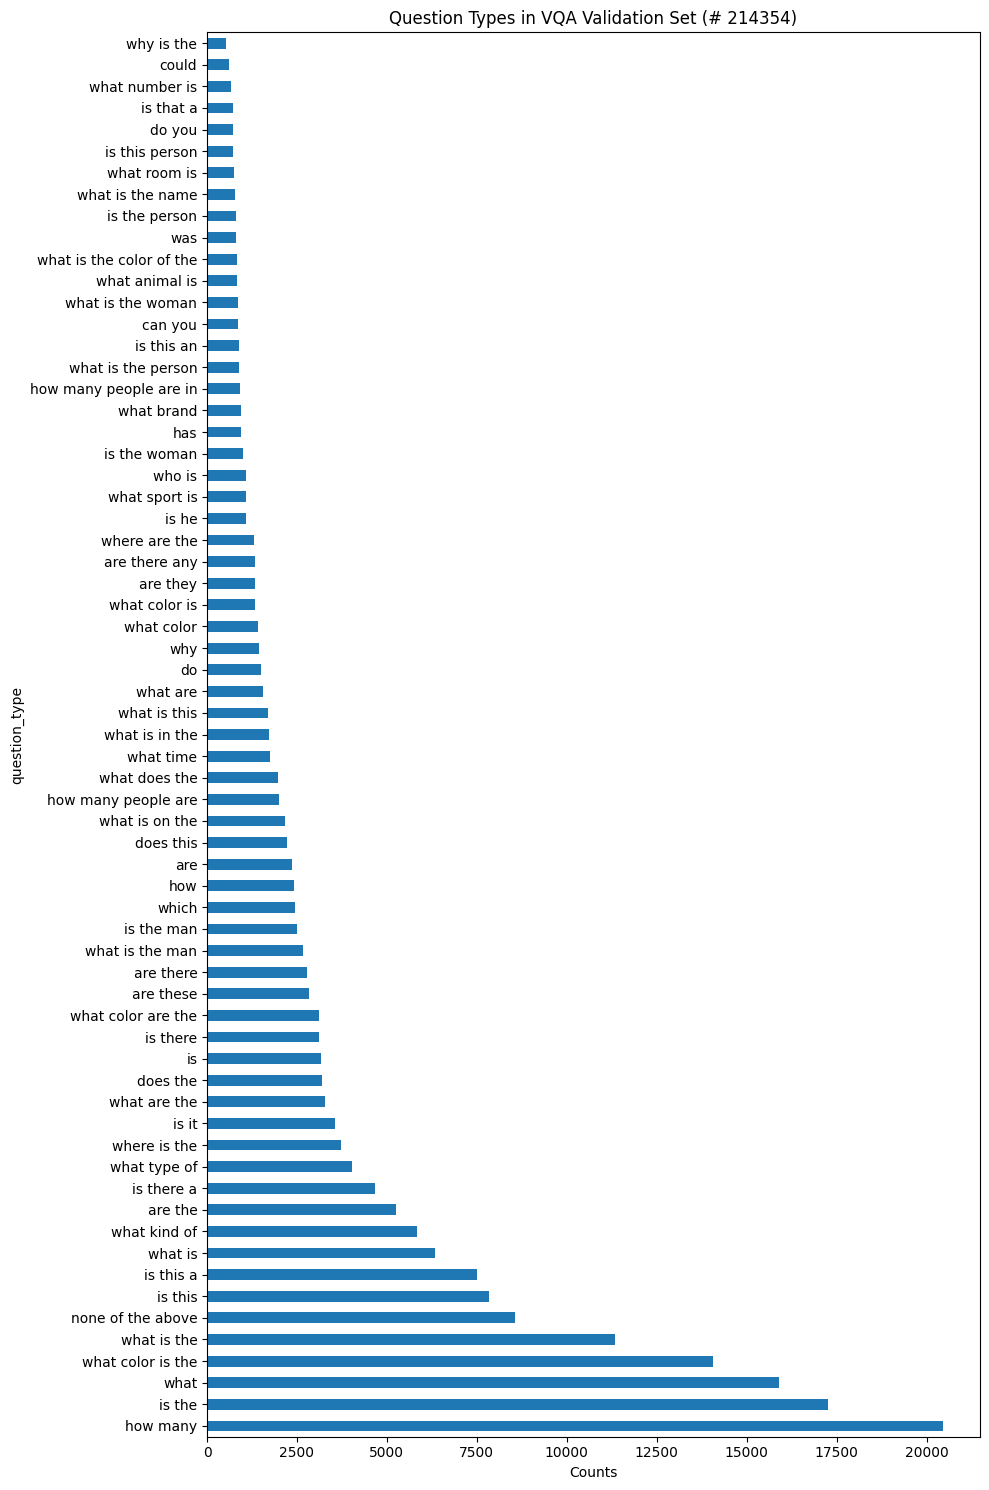

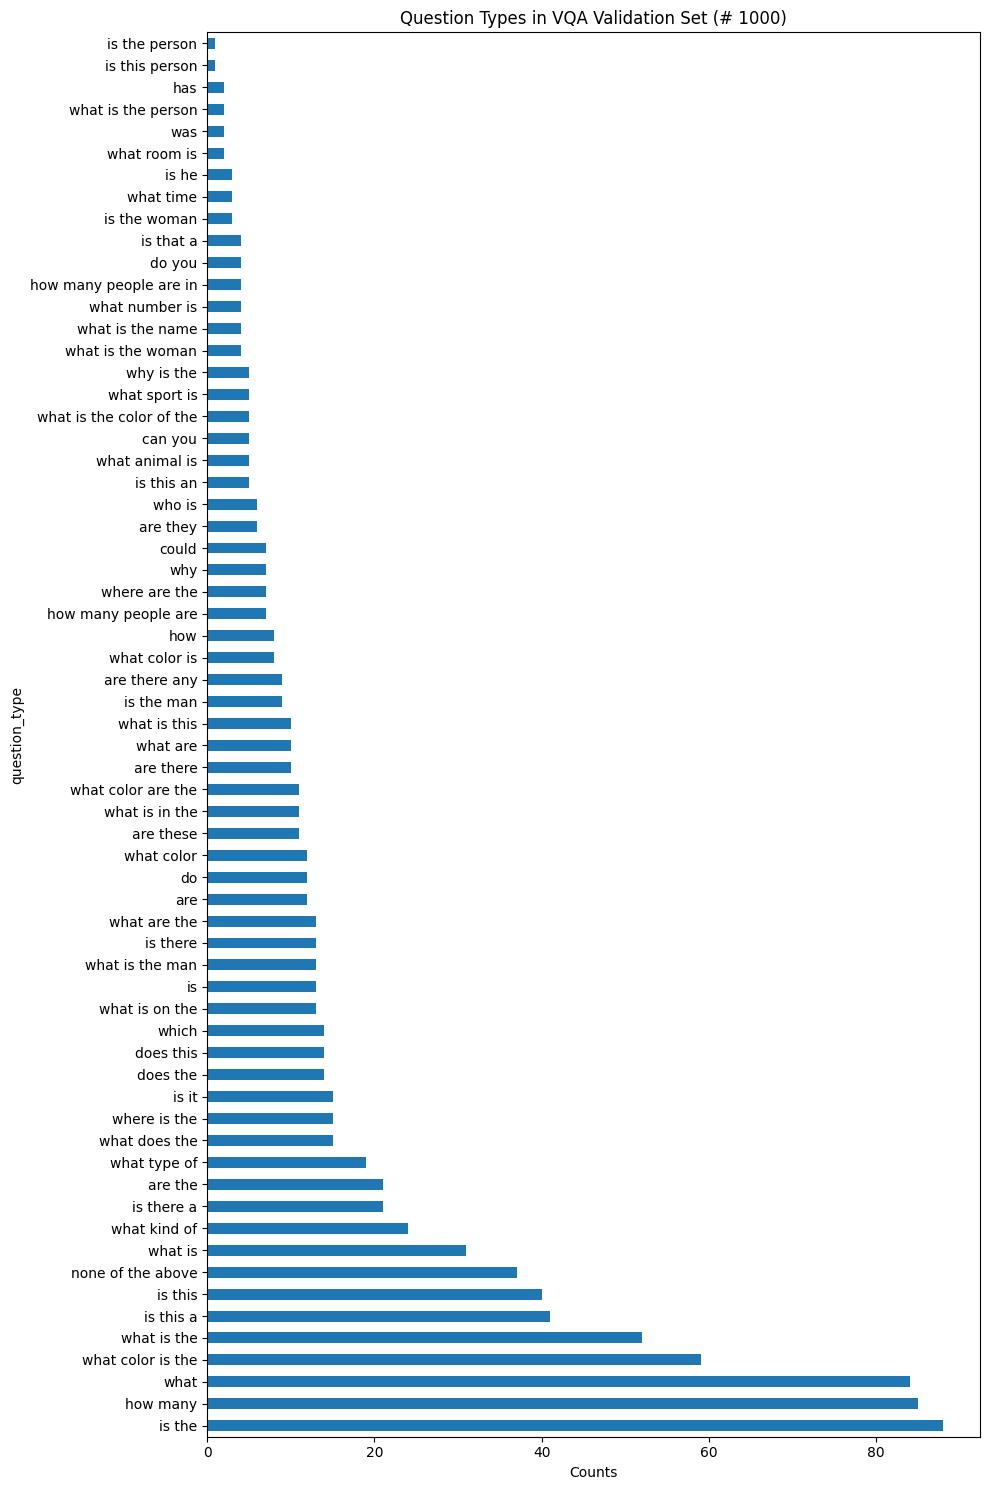

({'image_id': 524577,
  'question': 'What number of clocks are on this tower?',
  'question_id': 524577006,
  'answer_type': 'number',
  'multiple_choice_answer': '1',
  'answers': [{'answer': '1', 'answer_confidence': 'yes', 'answer_id': 1},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 2},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 3},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 4},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 5},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 6},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 7},
   {'answer': '1', 'answer_confidence': 'maybe', 'answer_id': 8},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 9},
   {'answer': '1', 'answer_confidence': 'yes', 'answer_id': 10}],
  'question_type': 'what',
  'image': '/home/david/Desktop/yuna/data/val2014/COCO_val2014_000000524577.jpg'},
 1000)

In [ ]:
from utils.plot_cluster import show_qtype_proportion

filtered_indices = [i for i, q in enumerate(dataset.questions) if q['question_id'] in qids]
filtered_dataset = [dataset[i] for i in filtered_indices]

# subset 
human_dataset = [dataset[i] for i in [i for i, q in enumerate(dataset.questions) if q['question_id'] in hqids]]
df = show_qtype_proportion(human_dataset) 

# all questions 
original_dataset = show_qtype_proportion(dataset)
df = show_qtype_proportion(filtered_dataset) 
filtered_dataset[0], len(filtered_dataset) 

In [ ]:
grouped = df.groupby(['answer_type', 'question_type']).agg(question_id_count=('question_id', 'count')).reset_index()

    answer_type question_type  question_id_count
0        number       are the                  2
1        number     are there                  3
2        number     are these                  2
3        number       can you                  2
4        number      does the                  8
..          ...           ...                ...
138      yes/no  what are the                  2
139      yes/no       what is                  2
140      yes/no   what is the                  4
141      yes/no           why                  3
142      yes/no    why is the                  1

[143 rows x 3 columns]


In [41]:
from datasets import load_dataset

textvqa = load_dataset("lmms-lab/textvqa", split="validation")  
okvqa = load_dataset("lmms-lab/OK-VQA", split="val2014") 

Generating val2014 split: 100%|██████████| 5046/5046 [00:01<00:00, 3682.05 examples/s]
